In [2]:
!pip install -U scikit-learn==1.8.0

In [79]:
import pandas as pd
import numpy as np
df = pd.read_csv("kidney_disease.csv")

# its show the maximum COLUMNS and ROWS 

In [80]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [81]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


# 🧠📊  EDA 

# shape of data_set

In [82]:
df.shape

(400, 26)

# columns name 

In [83]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

# data types 

In [84]:
data= df.dtypes
pd.DataFrame(data)

,0
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


# counts null values 

In [85]:
null= df.isnull().sum()

null_data= pd.DataFrame(null).T

null_data

# null

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,9,12,47,46,49,152,65,4,4,44,19,17,87,88,52,70,105,130,2,2,2,1,1,1,0


# counts duplicate value 

In [86]:
df.duplicated().sum()

np.int64(0)

# show over all info 

In [87]:
info= df.info()

pd.DataFrame(info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

""


# over views of data_set with null values 

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,400.0,199.500000,115.614301,0.000,99.75,199.50,299.25,399.000
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000


# convert DATA_TYPES object to float64

In [89]:
cols = ["pcv", "wc", "rc"]

# 1. Replace dirty symbols
df[cols] = df[cols].replace(["?", "\t?"], np.nan)

# 2. Convert safely
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# 3. Convert datatype
df[cols] = df[cols].astype('float64')

# fill NaN values mode/median and Unknow value  

In [90]:
null= df.isnull().sum()

null_data= pd.DataFrame(null).T

null_data

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,9,12,47,46,49,152,65,4,4,44,19,17,87,88,52,71,106,131,2,2,2,1,1,1,0


In [91]:
pd.DataFrame([(df == "Unknow").sum()])

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [92]:
pd.DataFrame([df.dtypes])

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,int64,float64,float64,float64,float64,float64,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object


In [93]:
cols= ['rbc', 'pc', 'pcc', 'ba']

for col in cols:
    df[col] = df.groupby('classification')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
    )

# here missing the "age" coloumns 

In [94]:
cols= ['bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

df[cols]= df[cols].fillna(df[cols].median())

In [95]:
cols= ['htn', 'dm', 'cad', 'appet', 'pe', 'ane']

df[cols]= df[cols].fillna("Unknow")

# chack null values and data_types 

In [96]:
null= df.isnull().sum()

null_data= pd.DataFrame(null).T

null_data

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [97]:
pd.DataFrame([df.dtypes])

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,int64,float64,float64,float64,float64,float64,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object


In [98]:
df.head(3)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd


In [99]:
df.drop(columns='id', inplace=True)

In [100]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [101]:
pd.DataFrame([df.dtypes])

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,float64,float64,float64,float64,float64,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object


# drop columns 

In [102]:
#======== ye use kiya jata hai kyo data csv file me columns ka nam space ke sath hota hai like----- ' id'  or 'id ' esi ko remome karne ke liye es ka use kiya jata hai 
#df.columns= df.columns.str.strip()

# df.drop(columns= 'id', inplace= True)

In [103]:
if 'id' in df.columns: 
    df.drop(columns='id', inplace=True)

In [104]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# 📊 🧠 EDA by Graphs

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

# 1. over views of data_set with clean 

In [106]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.48,17.17,2.0,42.00,55.00,64.50,90.00
bp,400.0,76.58,13.49,50.0,70.00,80.00,80.00,180.00
sg,400.0,1.02,0.01,1.0,1.01,1.02,1.02,1.02
al,400.0,0.90,1.31,0.0,0.00,0.00,2.00,5.00
su,400.0,0.40,1.04,0.0,0.00,0.00,0.00,5.00
bgr,400.0,145.06,75.26,22.0,101.00,121.00,150.00,490.00
bu,400.0,56.69,49.40,1.5,27.00,42.00,61.75,391.00
sc,400.0,3.00,5.63,0.4,0.90,1.30,2.72,76.00
sod,400.0,137.63,9.21,4.5,135.00,138.00,141.00,163.00
pot,400.0,4.58,2.82,2.5,4.00,4.40,4.80,47.00


In [107]:
df.head(2)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.02,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.02,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd


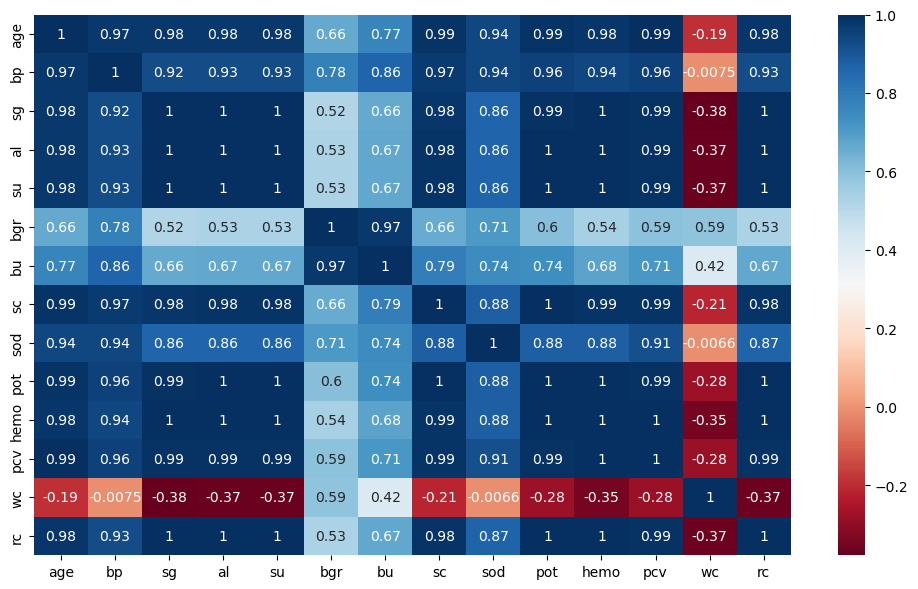

In [108]:
data= df.describe()

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='RdBu')
plt.tight_layout()
plt.show()



# 📌 Meaning:
# 1 → same column
# +1 → strong positive relation
# -1 → strong negative relation
# 0 → no relation

In [109]:
# print(plt.colormaps())

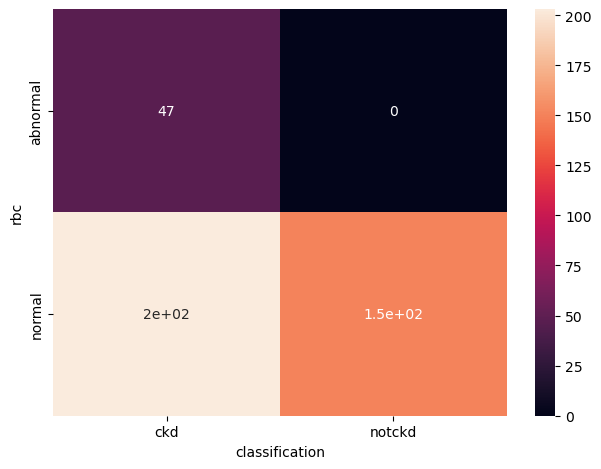

In [110]:
df = df.replace(r'\t', '', regex=True)

sns.heatmap(pd.crosstab(df['rbc'], df['classification']), annot=True)

plt.tight_layout()

In [111]:
# df['age_group'] = pd.cut(df['age'], bins=5)

# sns.heatmap(
#     df.pivot_table(index='age_group', columns='bp', values='bgr', aggfunc='mean', observed=False)
# )

# plt.tight_layout()

In [112]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


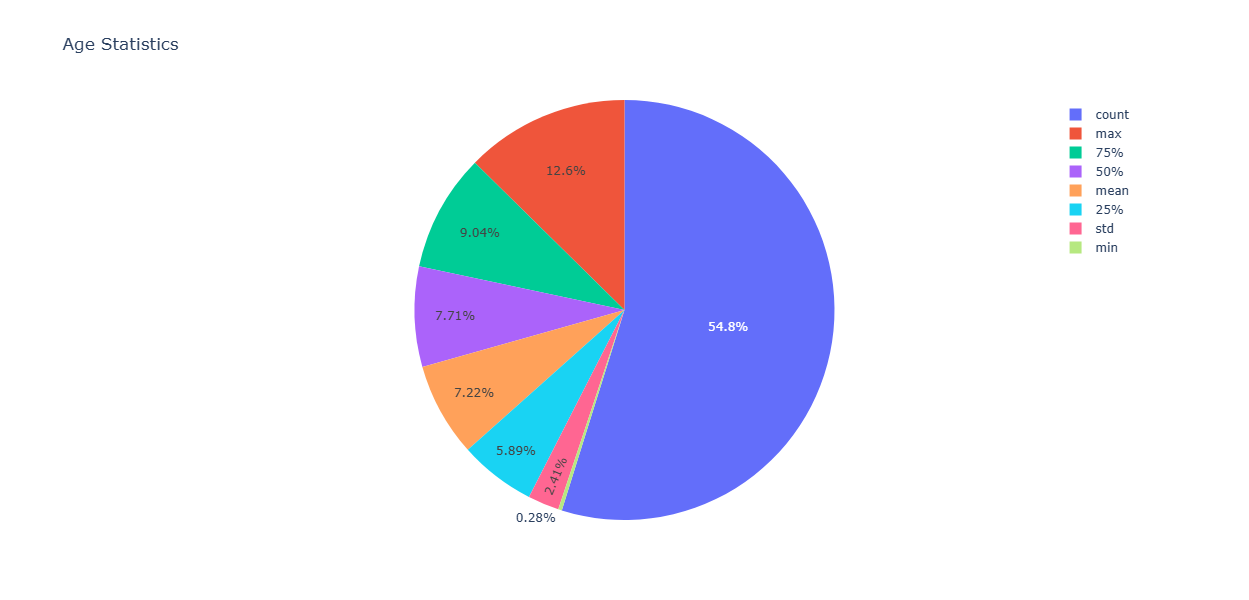

In [113]:
# plt.figure(figsize=(6, 6))
data= df['age'].describe()


fig= px.pie(
    names=data.index,
    values=data.values,
    title="Age Statistics"
)

fig.update_layout(
    width= 600,
    height= 600
)
#px.pie(data, labels=data.index, autopct='%1.1f%%')

# plt.title("Age Group Distribution")
# plt.tight_layout()

In [114]:
mins= df.groupby("rbc")["age"].min()
maxs= df.groupby("rbc")["age"].max()
medians= df.groupby("rbc")["age"].median()

data_frm= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

data_frm

,mins,maxs,medians
rbc,,,
abnormal,6.0,73.0,56.0
normal,2.0,90.0,54.0


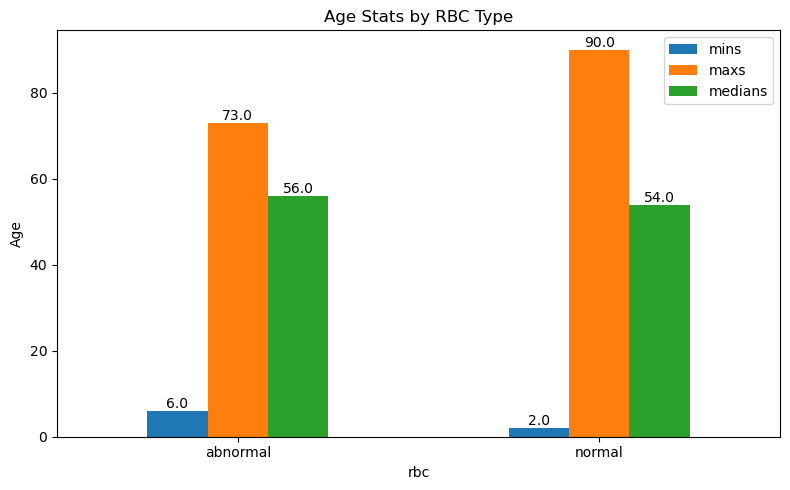

,mins,maxs,medians
rbc,,,
abnormal,6.0,73.0,56.0
normal,2.0,90.0,54.0


In [115]:
mins= df.groupby("rbc")["age"].min()
maxs= df.groupby("rbc")["age"].max()
medians= df.groupby("rbc")["age"].median()

data_frm= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

ax= data_frm.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Age Stats by RBC Type")
plt.ylabel("Age")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

data_frm

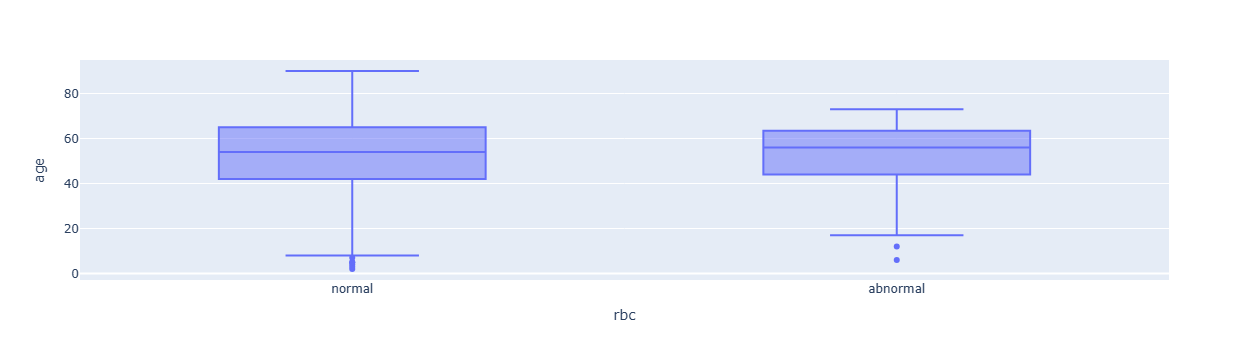

In [116]:
px.box(
    df,
    x="rbc",
    y="age"
)

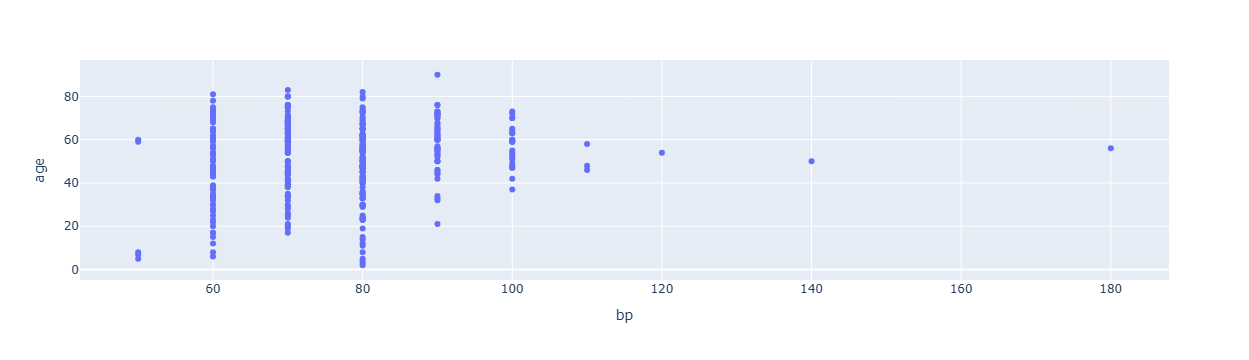

In [117]:
px.scatter(
    df,
    x= "bp",
    y= "age"
)

In [118]:
mins= df['age'].min()
maxs= df['age'].max()
medians= df['age'].mean()

data_fram= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
}, index=[0])

data_fram

,mins,maxs,medians
0,2.0,90.0,51.483376


,mins,maxs,medians
rbc,,,
abnormal,60.0,110.0,80.0
normal,50.0,180.0,80.0


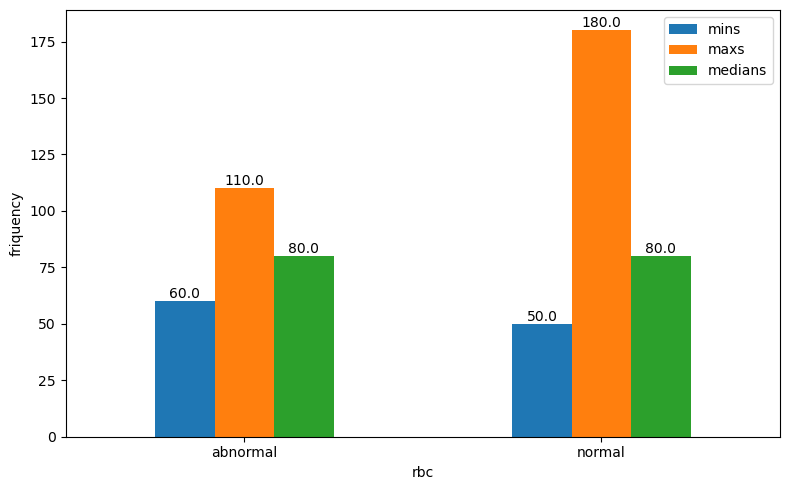

In [119]:
mins= df.groupby("rbc")["bp"].min()
maxs= df.groupby("rbc")["bp"].max()
medians= df.groupby("rbc")["bp"].median()

data_fram= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

ax= data_fram.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.ylabel("friquency")
plt.xticks(rotation= 0)

plt.tight_layout()


data_fram

bp,50.0,60.0,70.0,80.0,90.0,100.0,110.0,120.0,140.0,180.0
age,5.0,6.0,17.0,2.0,21.0,37.0,46.0,54.0,50.0,56.0


<Figure size 1000x500 with 0 Axes>

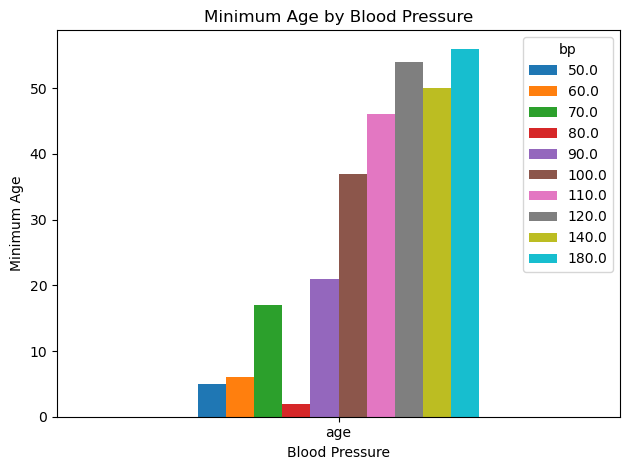

In [120]:
data= pd.DataFrame([df.groupby("bp")["age"].min()])

plt.figure(figsize=(10,5))
data.plot(kind='bar')

plt.title("Minimum Age by Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Minimum Age")
plt.xticks(rotation=0)
plt.tight_layout()

data

,mins,maxs,medians
pc,,,
abnormal,50.0,180.0,80.0
normal,50.0,140.0,80.0


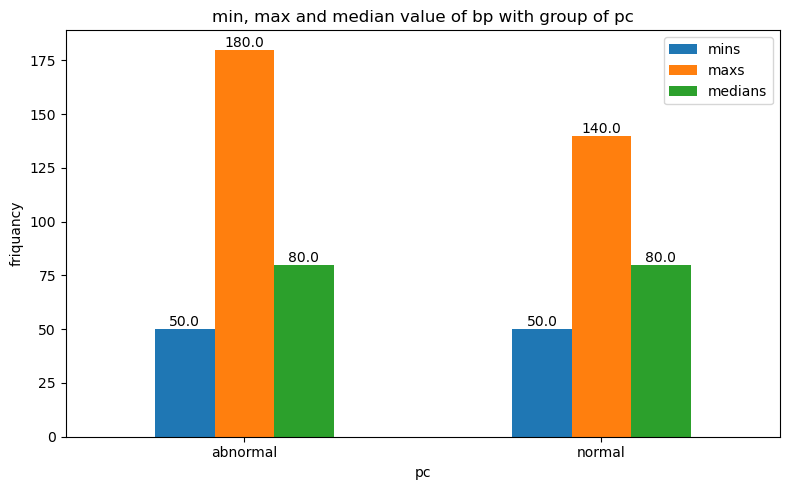

In [121]:
mins= df.groupby("pc")["bp"].min()
maxs= df.groupby("pc")["bp"].max()
medians= df.groupby("pc")["bp"].median()

data_frm_pc= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

ax= data_frm_pc.plot(kind= 'bar', figsize= (8,5))

for container in ax.containers:
    ax.bar_label(container, fmt= '%.1f')

plt.ylabel("friquancy")
plt.title("min, max and median value of bp with group of pc")
plt.xticks(rotation=0)

plt.tight_layout()

data_frm_pc

,mins,maxs,medians
pcc,,,
notpresent,50.0,180.0,80.0
present,60.0,110.0,75.0


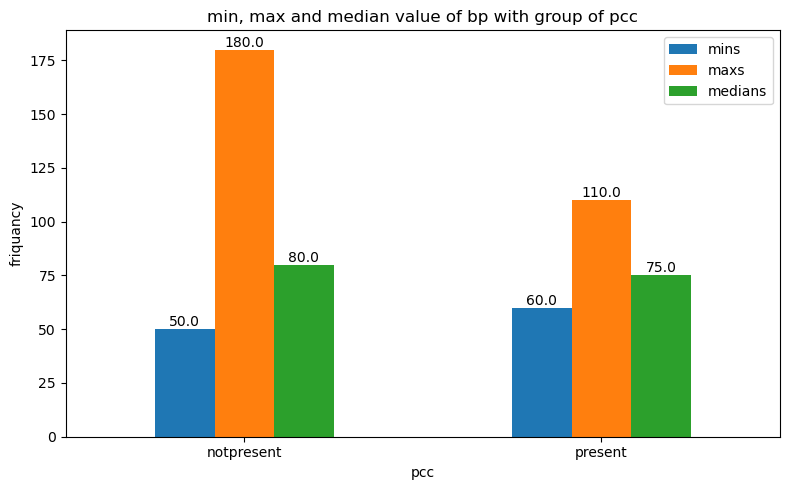

In [122]:
mins= df.groupby("pcc")["bp"].min()
maxs= df.groupby("pcc")["bp"].max()
medians= df.groupby("pcc")["bp"].median()

data_frm_pcc= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

ax= data_frm_pcc.plot(kind= 'bar', figsize= (8,5))

for container in ax.containers:
    ax.bar_label(container, fmt= '%.1f')

plt.ylabel("friquancy")
plt.title("min, max and median value of bp with group of pcc")
plt.xticks(rotation=0)

plt.tight_layout()

data_frm_pcc

,mins,maxs,medians
ba,,,
notpresent,50.0,180.0,80.0
present,60.0,100.0,85.0


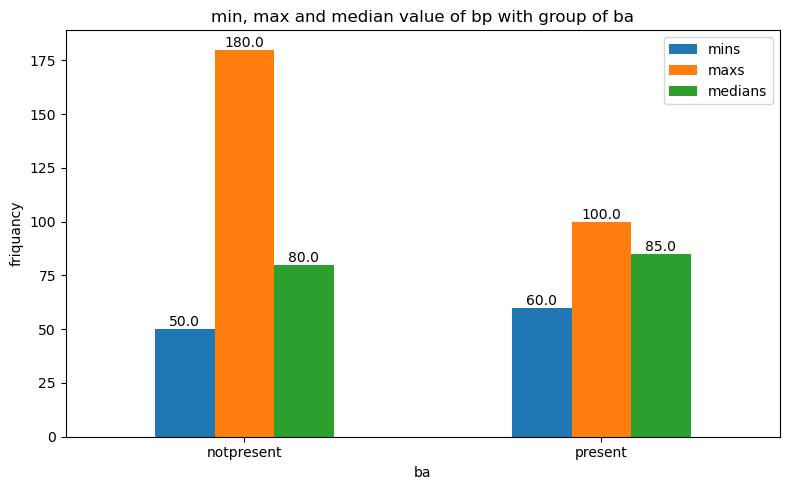

In [123]:
mins= df.groupby("ba")["bp"].min()
maxs= df.groupby("ba")["bp"].max()
medians= df.groupby("ba")["bp"].median()

data_frm_ba= pd.DataFrame({
    "mins": mins,
    "maxs": maxs,
    "medians": medians
})

ax= data_frm_ba.plot(kind= 'bar', figsize= (8,5))

for container in ax.containers:
    ax.bar_label(container, fmt= '%.1f')

plt.ylabel("friquancy")
plt.title("min, max and median value of bp with group of ba")
plt.xticks(rotation=0)

plt.tight_layout()

data_frm_ba


In [124]:
df.head(3)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.02,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.02,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd


In [125]:
# df.drop(columns='age', inplace=True)

In [126]:
folt_col = df.select_dtypes(include="float64").columns
df[folt_col]= df[folt_col].astype("float32")

In [127]:
df.dtypes

age               float32
bp                float32
sg                float32
al                float32
su                float32
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float32
bu                float32
sc                float32
sod               float32
pot               float32
hemo              float32
pcv               float32
wc                float32
rc                float32
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [128]:
(df == "Unknow").sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               2
dm                2
cad               2
appet             1
pe                1
ane               1
classification    0
dtype: int64

In [129]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [130]:
df.groupby("pe").count()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,ane,classification
pe,,,,,,,,,,,,,,,,,,,,,,,,
Unknow,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
no,316,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323,323
yes,74,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76,76


In [131]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [132]:
df.isnull().sum()

age               9
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

# Validation Function

In [133]:
ALLOWED_NULL_COLS = ['htn', 'dm', 'cad', 'appet', 'pe', 'ane']

def validate_input(df):

    invalid_cols = []

    for col in df.columns:
        if col not in ALLOWED_NULL_COLS:
            if df[col].isnull().any():
                invalid_cols.append(col)

    if invalid_cols:
        raise ValueError(
            f"Null values are NOT allowed in: {', '.join(invalid_cols)}"
        )


# Target

In [134]:

le = LabelEncoder()
df["classification"] = le.fit_transform(df["classification"])

X = df.drop("classification", axis=1)
y = df["classification"]


# Column Types nul_cols, cat_col


In [135]:
num_cols = X.select_dtypes(
    include=["float32"]
).columns.tolist()

cat_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()


# Column Types num_pipeline, cat_pipeline

In [136]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessing


In [137]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


# Full Pipeline

In [138]:
model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])


# Train Test Split

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train


In [140]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

# Accuracy

In [141]:
# validate_input(X_test)

pred = model_pipeline.predict(X_test)

print(
    "Model Prediction Accuracy:",
    accuracy_score(y_test, pred)
)

Model Prediction Accuracy: 0.975


In [142]:
import pickle

pickle.dump(model_pipeline, open("model.pkl", "wb"))

In [143]:
import sklearn
print(sklearn.__version__)

1.8.0
